# Trajectory Inference with Slingshot

Here we use pancreas endocrine development data to demonstrate Slingshot lineage fitting, pseudotime visualization, and lineage-aware dynamic summaries.

## Method background

Following the [Bioconductor Slingshot vignette](https://bioconductor.org/packages/release/bioc/vignettes/slingshot/inst/doc/vignette.html) and the original [BMC Genomics paper](https://bmcgenomics.biomedcentral.com/articles/10.1186/s12864-018-4772-0), Slingshot combines cluster topology with smooth curve fitting.

Its core logic is:

- cluster cells in a reduced-dimensional embedding
- connect clusters with a minimum spanning tree to recover global lineage structure
- fit simultaneous principal curves through the connected clusters
- assign lineage-specific pseudotime values, while allowing cells to share an early trunk

This design makes Slingshot a strong choice when lineage topology is easier to interpret at the cluster level than at the single-cell level.

## Why use the pancreas dataset here?

The pancreas dataset contains a compact branching structure with a visible endocrine trunk and terminal endocrine states. That makes it a good example for showing how Slingshot fits lineages and how lineage-specific trends can be summarized downstream.

## Preprocess data

As an example, we apply trajectory inference to pancreas development.


In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import omicverse as ov
ov.plot_set(font_path='Arial')

%load_ext autoreload
%autoreload 2

🔬 Starting plot initialization...
Using already downloaded Arial font from: /var/folders/rv/3jnfbs0d6r7d0c5bfj7ft5k00000gn/T/omicverse_arial.ttf


Matplotlib is building the font cache; this may take a moment.


Registered as: Arial
🧬 Detecting GPU devices…
✅ Apple Silicon MPS detected
    • [MPS] Apple Silicon GPU - Metal Performance Shaders available

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.3rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



In [2]:
adata=ov.datasets.pancreatic_endocrinogenesis()

⚠️ File ./data/endocrinogenesis_day15.h5ad already exists
 Loading data from ./data/endocrinogenesis_day15.h5ad


✅ Successfully loaded: 3696 cells × 27998 genes


In [3]:
adata=ov.pp.preprocess(adata,mode='shiftlog|pearson',n_HVGs=3000,)
adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]
ov.pp.scale(adata)
ov.pp.pca(adata,layer='scaled',n_pcs=50)

🔍 [2026-04-25 11:12:32] Running preprocessing in 'cpu' mode...
Begin robust gene identification


    After filtration, 17750/27998 genes are kept.
    Among 17750 genes, 16426 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson

🔍 Count Normalization:
   Target sum: 500000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2


   ⚠️ Excluding 1 highly-expressed genes from normalization computation
   Excluded genes: ['Ghrl']

✅ Count Normalization Completed Successfully!
   ✓ Processed: 3,696 cells × 16,426 genes
   ✓ Runtime: 0.09s

🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 3,000
   Theta (overdispersion): 100



✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 3,000 highly variable genes out of 16,426 total (18.3%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': Float vector (adata.var)
     • 'highly_variable_nbatches': Int vector (adata.var)
     • 'highly_variable_intersection': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'variances': Float vector (adata.var)
     • 'residual_variances': Float vector (adata.var)
    Time to analyze data in cpu: 0.69 seconds.
✅ Preprocessing completed successfully.
    Added:
        'highly_variable_features', boolean vector (adata.var)
        'means', float vector (adata.var)
        'variances', float vector (adata.var)
        'residual_variances', float vector (adata.var)
        'counts', raw counts layer (adata.layers)
    End of size normalization: shiftlog and HVGs selection pearson

╭─ SUMMARY: preprocess ───────────────────


╭─ SUMMARY: scale ───────────────────────────────────────────────────╮
│  Duration: 0.307s                                                  │
│  Shape:    3,696 x 3,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● LAYERS │ ✚ scaled (array, 3696x3000)                            │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
computing PCA🔍
    with n_comps=50
   🖥️ Using sklearn PCA for CPU computation
   🖥️ sklearn PCA backend: CPU computation
   📊 PCA input data type: ArrayView, shape: (3696, 3000), dtype: float64


   🔧 PCA solver used: covariance_eigh
    finished✅ (4.31s)

╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 4.3166s                                                 │
│  Shape:    3,696 x 3,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ scaled|original|cum_sum_eigenvalues                  │
│           │ ✚ scaled|original|pca_var_ratios                       │
│                                                                    │
│  ● OBSM   │ ✚ scaled|original|X_pca (array, 3696x50)               │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


Let us inspect the contribution of single PCs to the total variance in the data. This gives us information about how many PCs we should consider in order to compute the neighborhood relations of cells. In our experience, often a rough estimate of the number of PCs does fine.

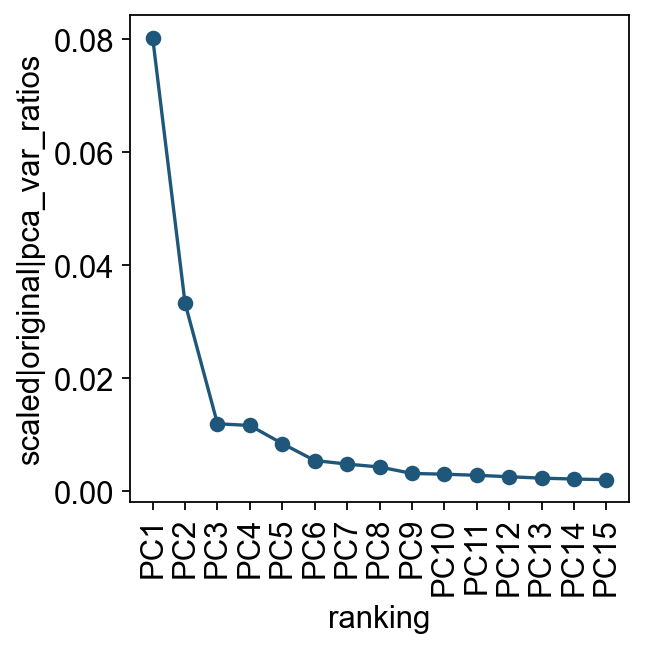

In [4]:
ov.utils.plot_pca_variance_ratio(adata, n_pcs=15)

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


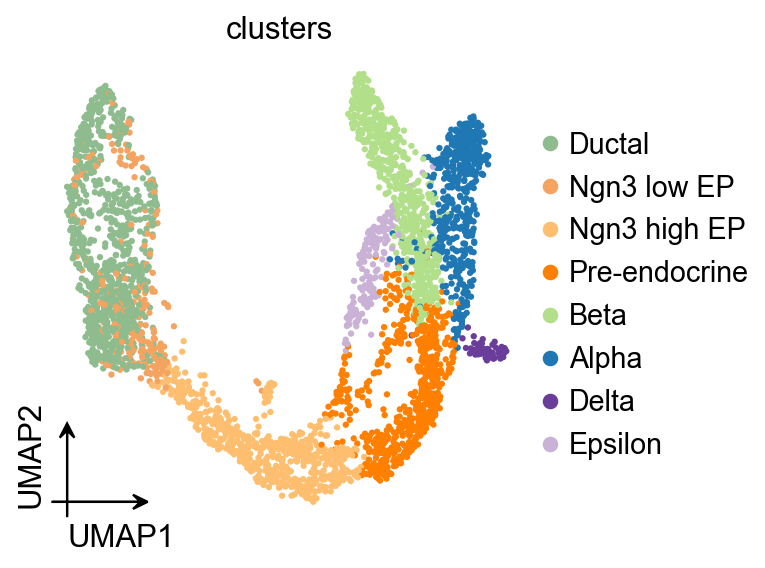

In [5]:
ov.pl.umap(
    adata,
    color='clusters'
)

## Slingshot

Provides functions for inferring continuous, branching lineage structures in low-dimensional data. Slingshot was designed to model developmental trajectories in single-cell RNA sequencing data and serve as a component in an analysis pipeline after dimensionality reduction and clustering. It is flexible enough to handle arbitrarily many branching events and allows for the incorporation of prior knowledge through supervised graph construction.

In [6]:
Traj=ov.single.TrajInfer(
    adata,basis='X_umap',
    groupby='clusters',
    use_rep='scaled|original|X_pca',
    n_comps=50
)
Traj.set_origin_cells('Ductal')
#Traj.set_terminal_cells(["Granule mature","OL","Astrocytes"])

If you only need the proposed timing and not the lineage of the process, then you can leave the debug_axes parameter unset.

In [7]:
Traj.inference(method='slingshot',num_epochs=1)

Lineages: [Lineage[3, 6, 5, 7, 1, 0], Lineage[3, 6, 5, 7, 1, 4], Lineage[3, 6, 5, 7, 2]]


  0%|          | 0/1 [00:00<?, ?it/s]

Reversing from leaf to root
Averaging branch @1 with lineages: [0, 1] [<pcurvepy2.pcurve.PrincipalCurve object at 0x148950710>, <pcurvepy2.pcurve.PrincipalCurve object at 0x1488f7550>]


Averaging branch @7 with lineages: [0, 1, 2] [<pcurvepy2.pcurve.PrincipalCurve object at 0x1489b6f90>, <pcurvepy2.pcurve.PrincipalCurve object at 0x148870790>]


Shrinking branch @7 with curves: [<pcurvepy2.pcurve.PrincipalCurve object at 0x1489b6f90>, <pcurvepy2.pcurve.PrincipalCurve object at 0x148870790>]


Shrinking branch @1 with curves: [<pcurvepy2.pcurve.PrincipalCurve object at 0x148950710>, <pcurvepy2.pcurve.PrincipalCurve object at 0x1488f7550>]


else, you can set `debug_axes` to visualize the lineage

Lineages: [Lineage[3, 6, 5, 7, 1, 0], Lineage[3, 6, 5, 7, 1, 4], Lineage[3, 6, 5, 7, 2]]


  0%|          | 0/1 [00:00<?, ?it/s]

Reversing from leaf to root
Averaging branch @1 with lineages: [0, 1] [<pcurvepy2.pcurve.PrincipalCurve object at 0x133a9b0d0>, <pcurvepy2.pcurve.PrincipalCurve object at 0x148737850>]


Averaging branch @7 with lineages: [0, 1, 2] [<pcurvepy2.pcurve.PrincipalCurve object at 0x1486b8c50>, <pcurvepy2.pcurve.PrincipalCurve object at 0x148590a50>]


Shrinking branch @7 with curves: [<pcurvepy2.pcurve.PrincipalCurve object at 0x1486b8c50>, <pcurvepy2.pcurve.PrincipalCurve object at 0x148590a50>]


Shrinking branch @1 with curves: [<pcurvepy2.pcurve.PrincipalCurve object at 0x133a9b0d0>, <pcurvepy2.pcurve.PrincipalCurve object at 0x148737850>]


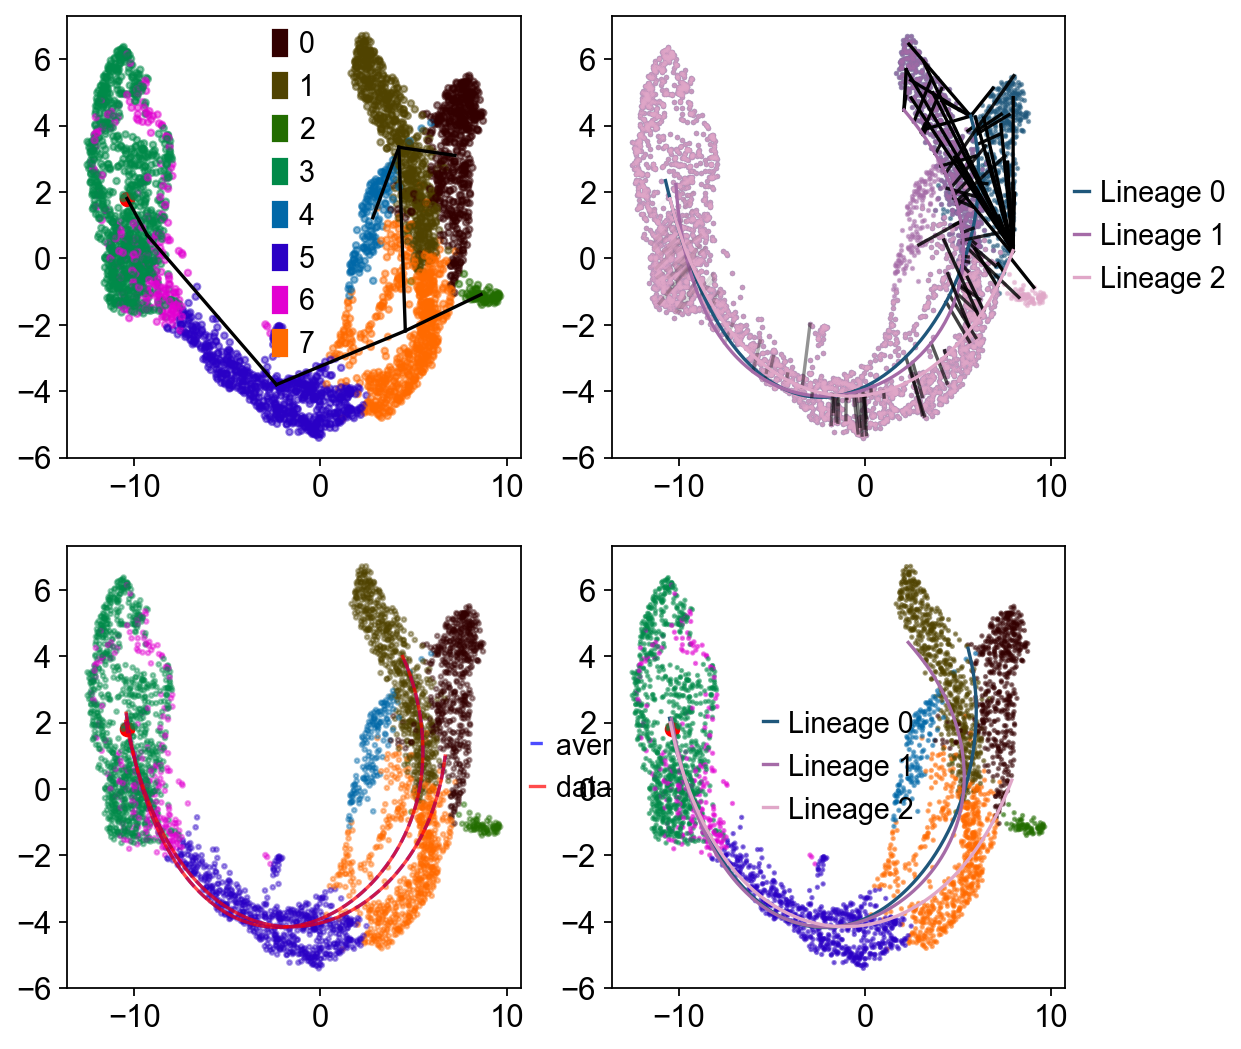

In [8]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))
Traj.inference(method='slingshot',num_epochs=1,debug_axes=axes)

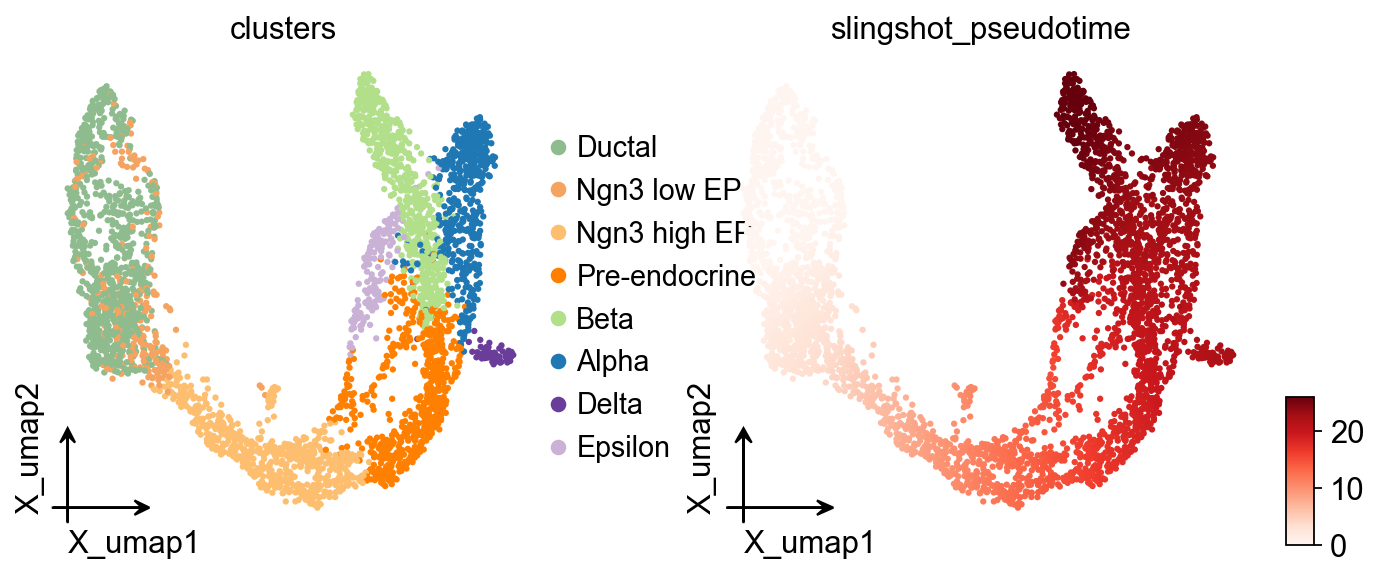

In [9]:
ov.pl.embedding(
    adata,basis='X_umap',
    color=['clusters','slingshot_pseudotime'],
    frameon='small',
    cmap='Reds'
)

In [10]:
sc.pp.neighbors(adata,use_rep='scaled|original|X_pca')
ov.utils.cal_paga(
    adata,
    use_time_prior='slingshot_pseudotime',
    vkey='paga',
    groups='clusters'
)

running PAGA using priors: ['slingshot_pseudotime']
    finished
added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns)
    'paga/transitions_confidence', velocity transitions (adata.uns)


<Axes: title={'center': 'PAGA Slingshot-graph'}>

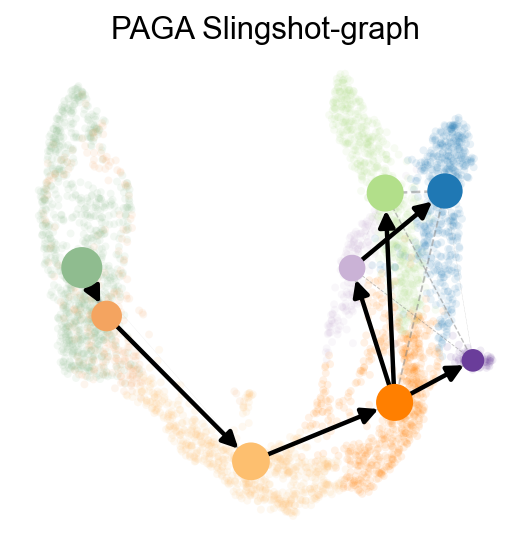

In [11]:
ov.utils.plot_paga(
    adata,basis='umap',
    size=50,
    alpha=.1,
    title='PAGA Slingshot-graph',
    min_edge_width=2,
    node_size_scale=1.5,
    show=False,
    legend_loc=False
)

### Summarize two Slingshot lineages with a mirrored dynamic heatmap

Slingshot can return multiple lineage curves. The snippet below converts the fitted curves into per-cell lineage labels and lineage-specific pseudotime, then plots two lineages side by side. We reverse the first lineage so the left panel points toward the branch point, which makes the branch-specific programs easier to compare.


In [12]:
import pandas as pd
import numpy as np

slingshot_genes = ['Sox9', 'Neurog3', 'Fev', 'Gcg', 'Arx', 'Pax4', 'Ins2', 'Pdx1', 'Sst', 'Hhex']

n_lineages = len(Traj.slingshot.lineages)
slingshot_lineage_labels = [f'Lineage {i}' for i in range(n_lineages)]

dominant_lineage = np.asarray(Traj.slingshot.cell_weights).argmax(axis=1)
lineage_specific_pt = np.full(adata.n_obs, np.nan)

for i, curve in enumerate(Traj.slingshot.curves):
    curve_pt = np.asarray(curve.pseudotimes_interp, dtype=float)
    adata.obs[f'slingshot_lineage_{i + 1}_pt'] = curve_pt
    lineage_specific_pt[dominant_lineage == i] = curve_pt[dominant_lineage == i]

adata.obs['slingshot_lineage'] = pd.Categorical(
    [slingshot_lineage_labels[i] for i in dominant_lineage],
    categories=slingshot_lineage_labels,
    ordered=True,
)
adata.obs['slingshot_lineage_pseudotime'] = lineage_specific_pt

selected_slingshot_lineages = slingshot_lineage_labels[:2]


🔍 Dynamic heatmap:
   Candidate features: 10
   Pseudotime: slingshot_lineage_pseudotime
   Lineage key: slingshot_lineage
   Cell annotation: clusters
   use_fitted=True | cell_bins=200 | cmap=RdBu_r
   Lineages: Lineage 0, Lineage 1



✅ Dynamic heatmap completed!
   ✓ Matrix shape: 10 features × 337 columns


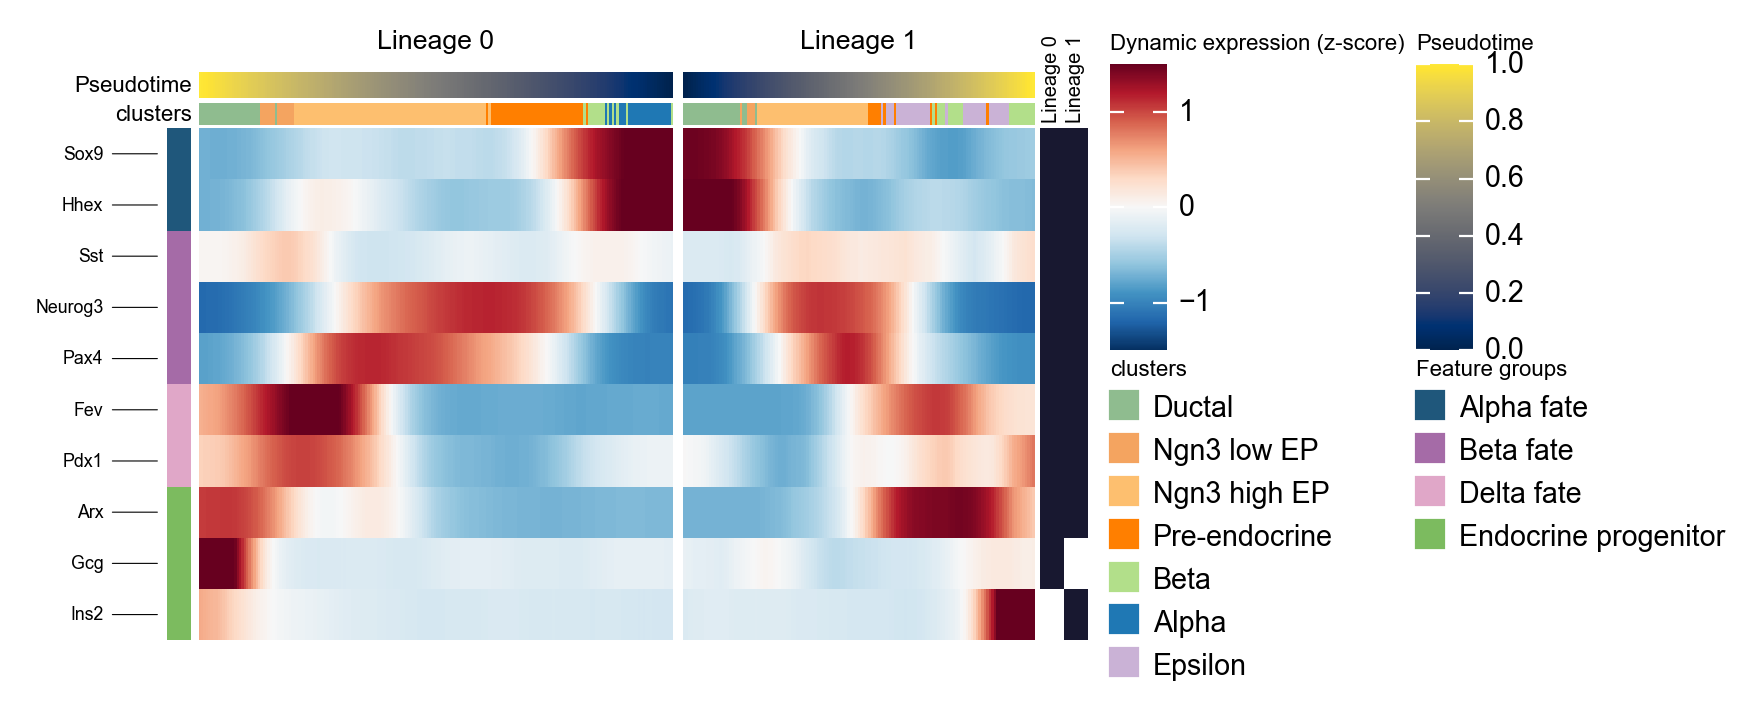

In [13]:
slingshot_marker = {
    'Alpha fate': ['Gcg', 'Arx'],
    'Beta fate': ['Pax4', 'Ins2', 'Pdx1'],
    'Delta fate': ['Sst', 'Hhex'],
    'Endocrine progenitor': ['Sox9', 'Neurog3', 'Fev'],
}

d1 = ov.pl.dynamic_heatmap(
    adata,
    var_names=slingshot_marker,
    pseudotime='slingshot_lineage_pseudotime',
    lineage_key='slingshot_lineage',
    lineages=selected_slingshot_lineages,
    reverse_ht=[selected_slingshot_lineages[0]],
    use_raw=adata.raw is not None,
    use_cell_columns=False,
    cell_annotation='clusters',
    cell_bins=200,
    smooth_window=17,
    fitted_window=31,
    figsize=(5, 4),
    standard_scale='var',
    cmap='RdBu_r',
    use_fitted=True,
    border=False,
    show=False,
)


🔍 Dynamic heatmap:
   Candidate features: 10
   Pseudotime: slingshot_lineage_pseudotime
   Lineage key: slingshot_lineage
   Cell annotation: clusters
   use_fitted=False | cell_bins=100 | cmap=viridis


   Lineages: Lineage 0, Lineage 1

✅ Dynamic heatmap completed!
   ✓ Matrix shape: 10 features × 183 columns


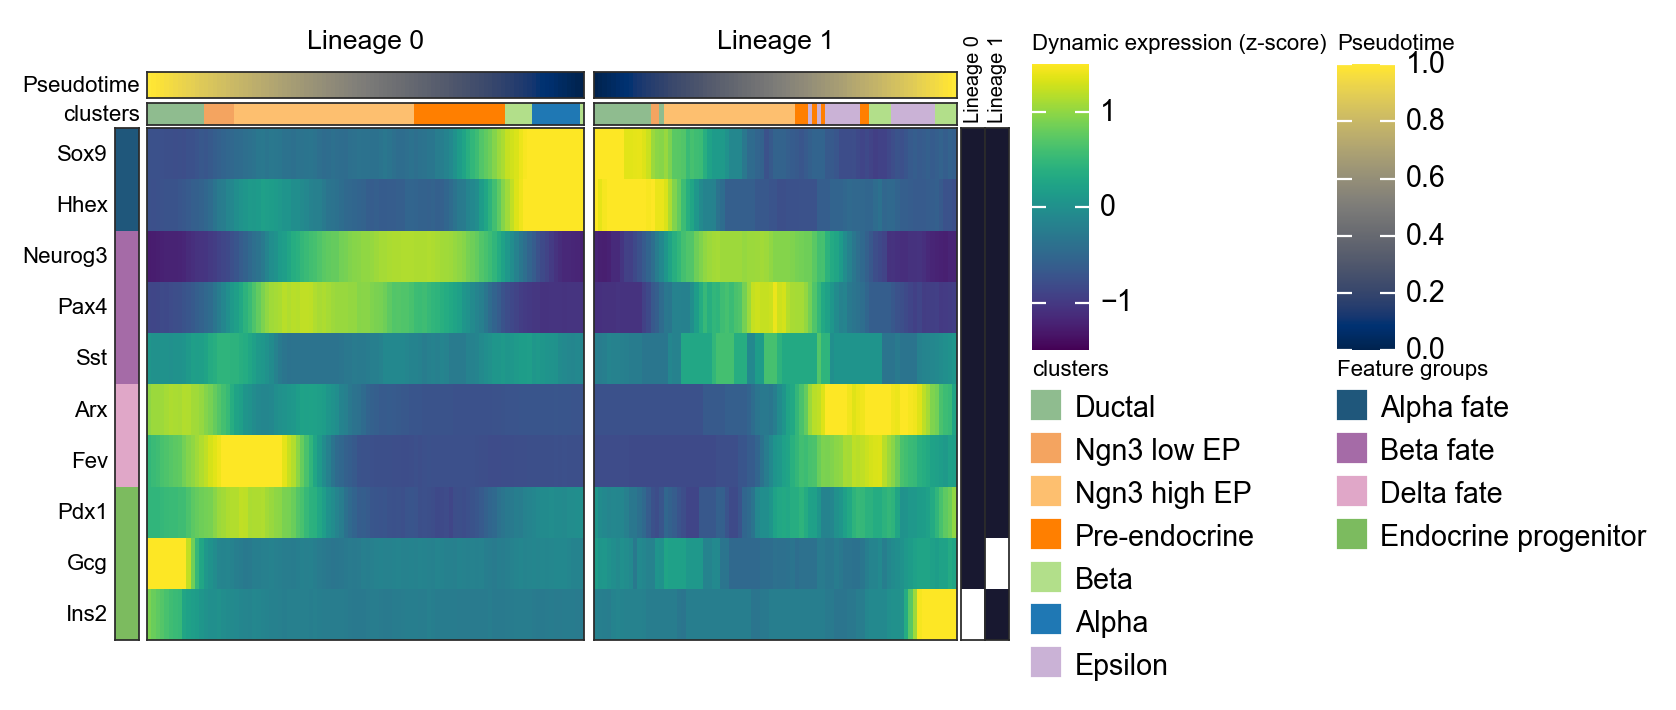

In [14]:
d1 = ov.pl.dynamic_heatmap(
    adata,
    var_names=slingshot_marker,
    pseudotime='slingshot_lineage_pseudotime',
    lineage_key='slingshot_lineage',
    lineages=selected_slingshot_lineages,
    reverse_ht=[selected_slingshot_lineages[0]],
    use_raw=adata.raw is not None,
    use_cell_columns=False,
    cell_annotation='clusters',
    figsize=(5, 4),
    standard_scale='var',
    show_row_names=True,
    use_fitted=False,
    border=True,
    show=False,
)

## Branch-aware pseudotime stream plot

`ov.pl.branch_streamplot` uses only a pseudotime vector and cell-state labels, so it can summarize the branch structure inferred by this method as a compact river-style plot. The width of each ribbon shows where a cell state is enriched along pseudotime, while the split centerlines highlight terminal endocrine fates.



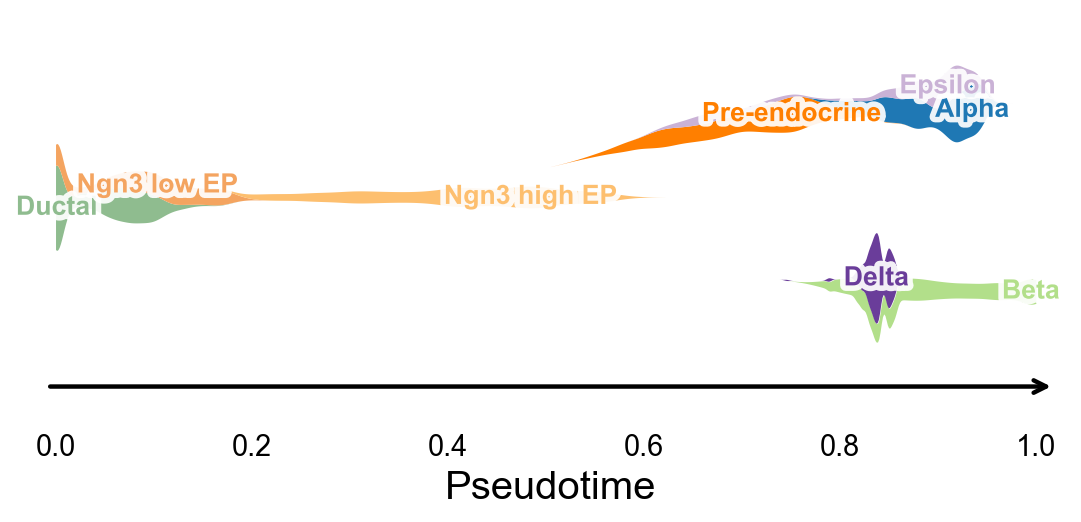

In [15]:
fig, ax = ov.pl.branch_streamplot(
    adata,
    group_key='clusters',
    pseudotime_key='slingshot_pseudotime',
    show=False,
)
plt.show()


### Fit `dynamic_features` / `dynamic_trends` across Slingshot lineages

We use two complementary views here. First, a global Slingshot trend fit summarizes marker activation along the shared pseudotime axis while keeping the raw points colored by clusters. Then we fit the same genes across Slingshot lineages and render a branch-aware panel that compares the lineage-specific curves after the endocrine split.

In [16]:
slingshot_trend_genes = ['Sox9', 'Neurog3', 'Fev', 'Gcg', 'Arx', 'Pax4', 'Ins2', 'Pdx1', 'Sst', 'Hhex']

slingshot_global_dyn = ov.single.dynamic_features(
    adata,
    genes=slingshot_trend_genes,
    pseudotime='slingshot_pseudotime',
    use_raw=adata.raw is not None,
    distribution='normal',
    link='identity',
    n_splines=8,
    store_raw=True,
    raw_obs_keys=['clusters'],
)



🔍 Dynamic feature analysis:
   Views: 1 | Features: 10
   Pseudotime: slingshot_pseudotime
   Stored raw obs keys: ['clusters']
   Expression source: adata.raw
   GAM: normal-identity | splines=8


Fitting dynamic features:   0%|          | 0/10 [00:00<?, ?it/s]


✅ Dynamic feature analysis completed!
   ✓ Successful fits: 10/10
   ✓ Fitted rows: 2000
   ✓ Raw observations stored: 36960


### Single-line global trends

This view fits one global curve per gene and colors the raw cells by annotation. It is useful for separating the overall pseudotime trend from the cell-state composition that appears around that trend.



🔍 Dynamic trend plotting:
   Features: 4 | Groups: 1
   compare_features=False | compare_groups=False


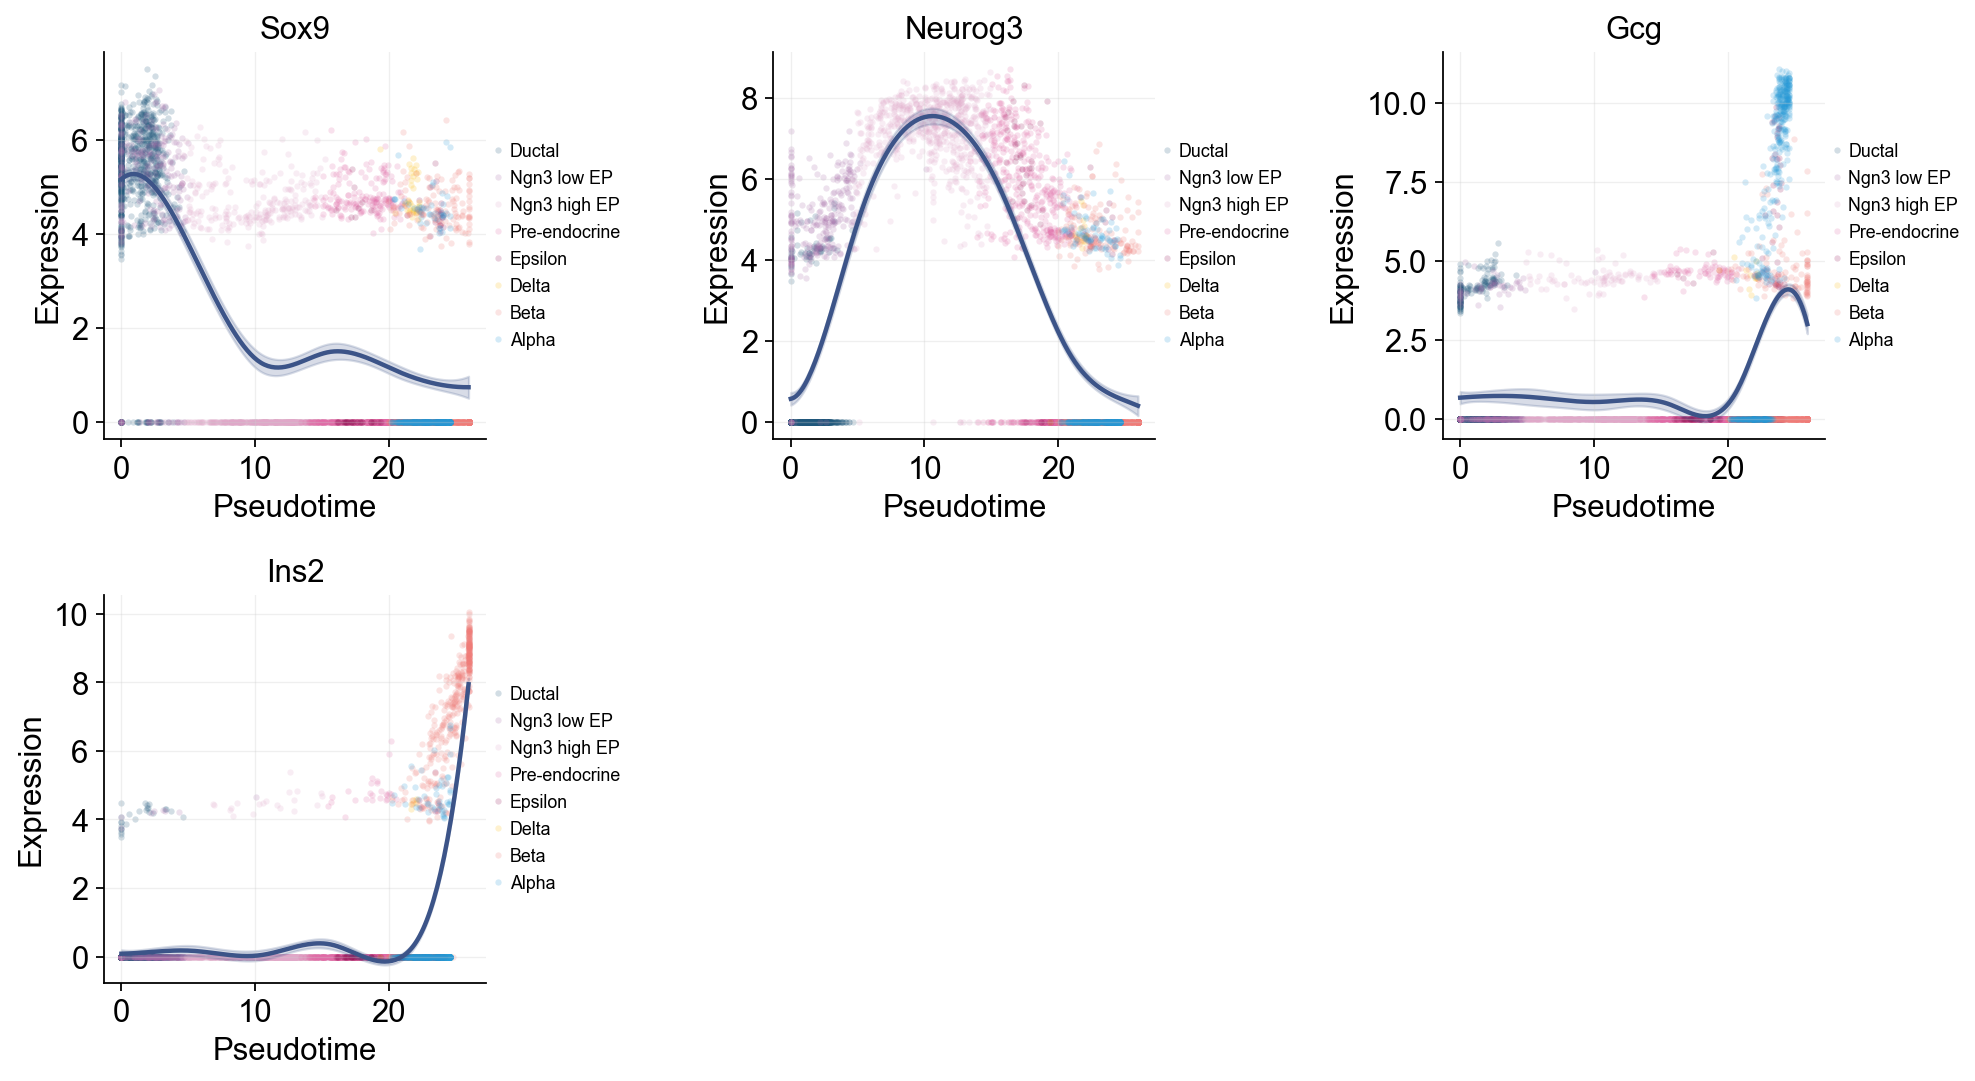

✅ Dynamic trend plotting completed!


In [17]:
ov.pl.dynamic_trends(
    slingshot_global_dyn,
    genes=['Sox9', 'Neurog3', 'Gcg', 'Ins2'],
    add_point=True,
    point_color_by='clusters',
    figsize=(5, 3.5),
    legend_loc='right margin',
    legend_fontsize=8,
)
plt.show()


### Multi-marker trend comparison

Here multiple marker curves are overlaid so their activation timing can be compared directly along the same pseudotime axis.



🔍 Dynamic trend plotting:
   Features: 4 | Groups: 1
   compare_features=True | compare_groups=False


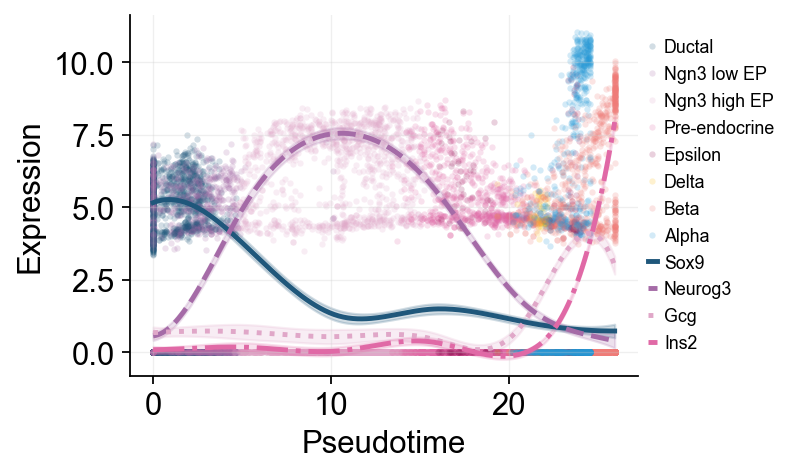

✅ Dynamic trend plotting completed!


In [18]:
ov.pl.dynamic_trends(
    slingshot_global_dyn,
    genes=['Sox9', 'Neurog3', 'Gcg', 'Ins2'],
    compare_features=True,
    add_point=True,
    point_color_by='clusters',
    line_style_by='features',
    figsize=(6.2, 3.2),
    linewidth=2.2,
    legend_loc='right margin',
    legend_fontsize=8,
)
plt.show()


In [19]:
slingshot_dyn_res = ov.single.dynamic_features(
    adata,
    genes=slingshot_trend_genes,
    pseudotime='slingshot_lineage_pseudotime',
    groupby='slingshot_lineage',
    groups=selected_slingshot_lineages,
    use_raw=adata.raw is not None,
    distribution='normal',
    link='identity',
    n_splines=8,
    store_raw=True,
)

slingshot_dyn_res.get_stats(successful_only=True).sort_values(['gene']).head(8)


🔍 Dynamic feature analysis:
   Views: 2 | Features: 10
   Pseudotime: slingshot_lineage_pseudotime
   Grouping: slingshot_lineage
   Expression source: adata.raw
   GAM: normal-identity | splines=8


Fitting dynamic features:   0%|          | 0/20 [00:00<?, ?it/s]


✅ Dynamic feature analysis completed!


   ✓ Successful fits: 20/20
   ✓ Fitted rows: 4000
   ✓ Raw observations stored: 30550


      dataset        groupby_key      group  gene  success error  n_cells  \
14  Lineage 1  slingshot_lineage  Lineage 1   Arx     True  None      533   
4   Lineage 0  slingshot_lineage  Lineage 0   Arx     True  None     2522   
2   Lineage 0  slingshot_lineage  Lineage 0   Fev     True  None     2522   
12  Lineage 1  slingshot_lineage  Lineage 1   Fev     True  None      533   
3   Lineage 0  slingshot_lineage  Lineage 0   Gcg     True  None     2522   
13  Lineage 1  slingshot_lineage  Lineage 1   Gcg     True  None      533   
9   Lineage 0  slingshot_lineage  Lineage 0  Hhex     True  None     2522   
19  Lineage 1  slingshot_lineage  Lineage 1  Hhex     True  None      533   

    exp_ncells  peak_time  valley_time  min_pseudotime  max_pseudotime  \
14         110  20.163205     8.026130             0.0       25.970730   
4          600  22.561005     7.726371             0.0       24.600767   
2         1010  19.594078     9.086213             0.0       24.600767   
12        


🔍 Dynamic trend plotting:
   Features: 4 | Groups: 2
   compare_features=False | compare_groups=True


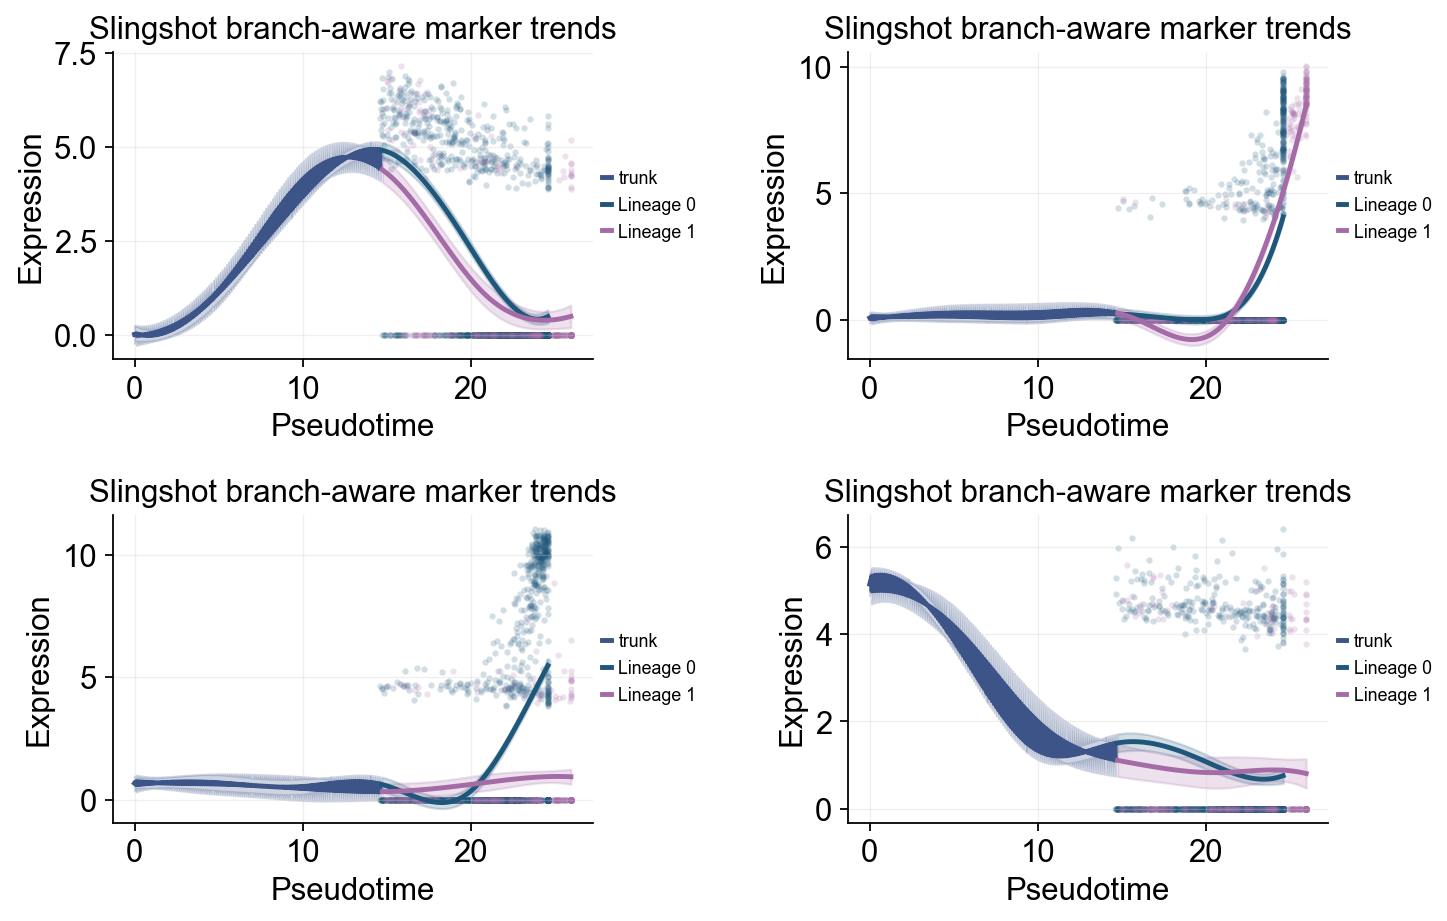

✅ Dynamic trend plotting completed!


In [20]:
slingshot_split_mask = adata.obs['clusters'].astype(str).isin(['Ngn3 high EP', 'Pre-endocrine'])
slingshot_split_time = float(np.nanmedian(adata.obs.loc[slingshot_split_mask, 'slingshot_lineage_pseudotime'])) if slingshot_split_mask.any() else float(np.nanmedian(adata.obs['slingshot_lineage_pseudotime']))

ov.pl.dynamic_trends(
    slingshot_dyn_res,
    genes=['Pax4', 'Ins2', 'Gcg', 'Sox9'],
    compare_groups=True,
    split_time=slingshot_split_time,
    shared_trunk=True,
    add_point=True,
    point_color_by='group',
    figsize=(5.5, 3),
    linewidth=2.2,
    ncols=2,
    legend_loc='right margin',
    legend_fontsize=8,
    title='Slingshot branch-aware marker trends',
)
plt.show()


🔍 Dynamic trend plotting:
   Features: 4 | Groups: 2
   compare_features=True | compare_groups=True


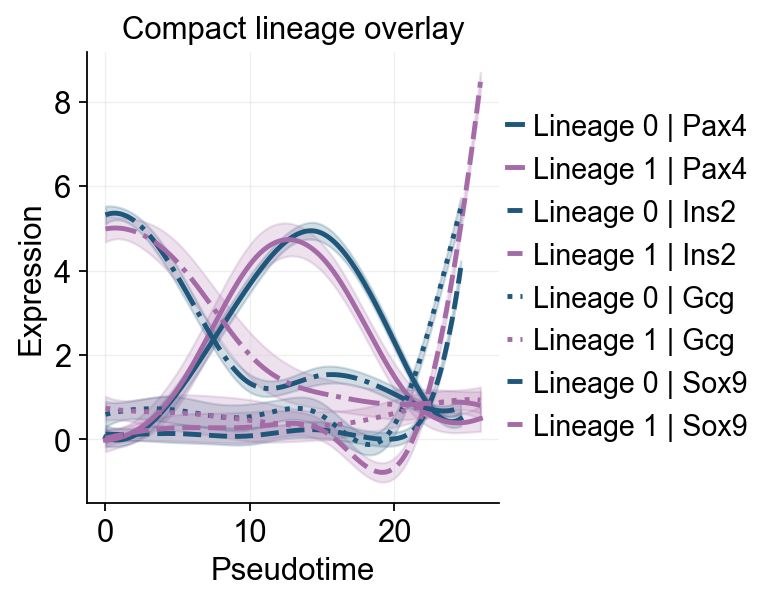

✅ Dynamic trend plotting completed!


In [21]:
ov.pl.dynamic_trends(
    slingshot_dyn_res,
    genes=['Pax4', 'Ins2', 'Gcg', 'Sox9'],
    compare_features=True,
    compare_groups=True,
    line_style_by='features',
    figsize=(6, 4),
    linewidth=2.2,
    title='Compact lineage overlay',
)
plt.show()


🔍 Dynamic heatmap:
   Candidate features: 3000
   Pseudotime: slingshot_lineage_pseudotime
   Lineage key: slingshot_lineage
   Cell annotation: clusters
   use_fitted=True | cell_bins=90 | cmap=viridis


   Lineages: Lineage 0, Lineage 1



✅ Dynamic heatmap completed!
   ✓ Matrix shape: 1000 features × 166 columns


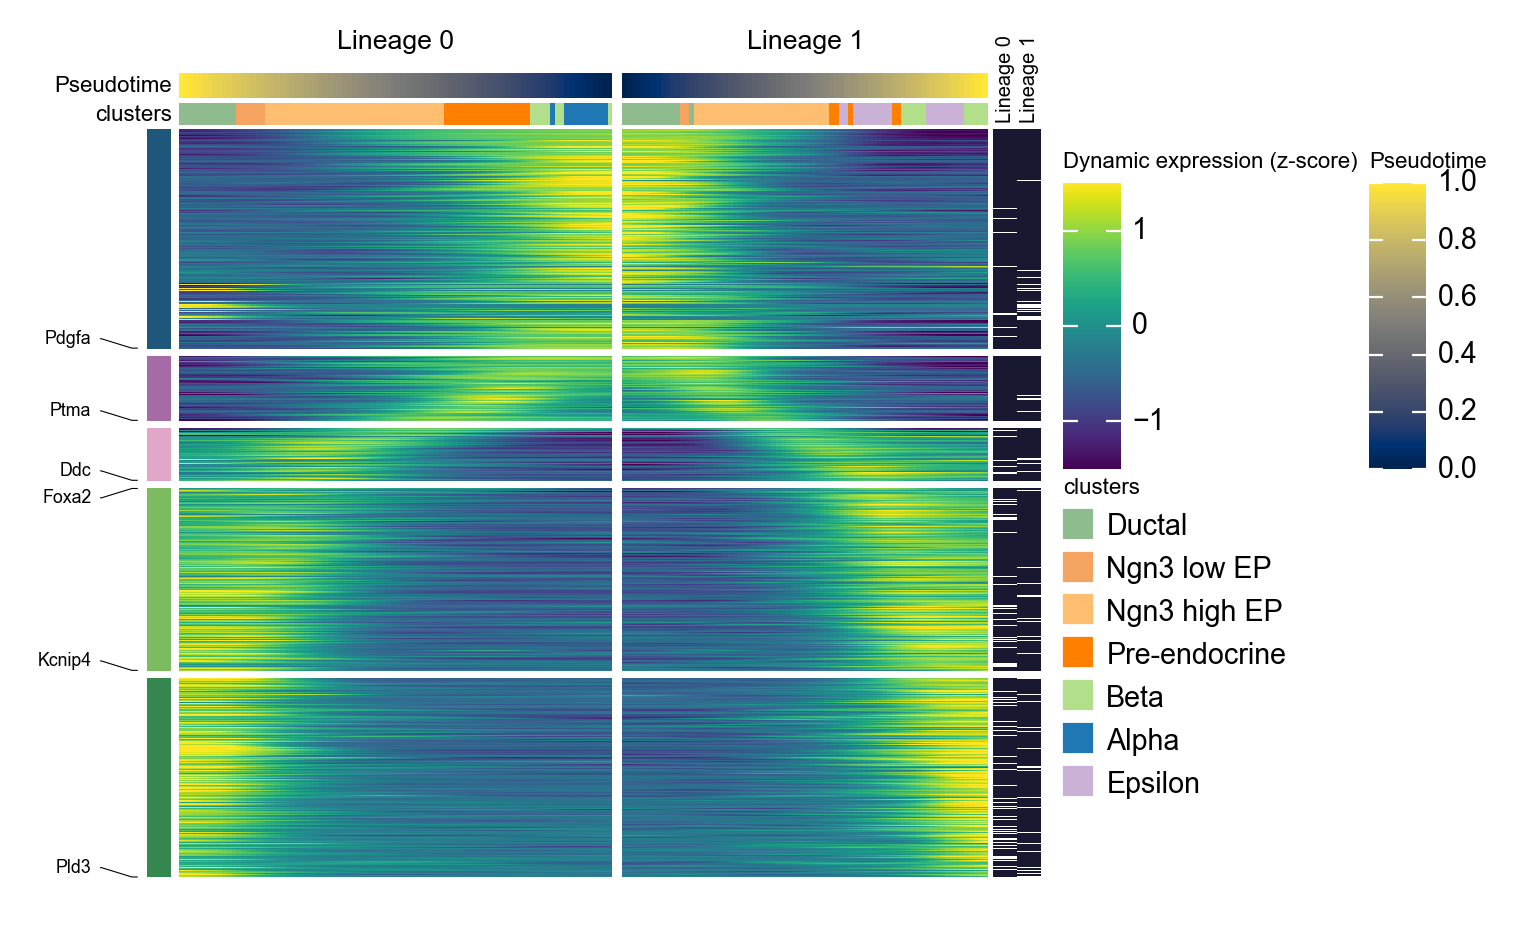

In [22]:
g = ov.pl.dynamic_heatmap(
    adata,
    top_features=1000,       # 保留动态性最强的前 1000 个基因用于绘图
    pseudotime='slingshot_lineage_pseudotime',
    lineage_key='slingshot_lineage',
    lineages=selected_slingshot_lineages,
    reverse_ht=[selected_slingshot_lineages[0]],
    use_raw=adata.raw is not None,
    use_cell_columns=False,
    cell_annotation='clusters',
    cell_bins=90,
    smooth_window=17,
    fitted_window=31,
    n_split=5,
    figsize=(5, 6),
    standard_scale='var',
    cmap='viridis',
    top_label_features=10,
    border=False,
    show=False,
)